In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor 
from sklearn.base import BaseEstimator, TransformerMixin


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

from ifc.config import load_data_config, load_split_config, resolve_project_root
from ifc.split import apply_forecasting_holdout_split, build_forecasting_test_frame

In [3]:

data_cfg = load_data_config() 
split_cfg = load_split_config()  
train_path, test_path = data_cfg.resolve_paths()    
print(data_cfg,"\n")

print(f'training path:{train_path}, exists? {train_path.exists()}')
print(f'tets path:{test_path}, exists? {test_path.exists()}')

id_col, time_col,drop_cols, target = data_cfg.id_col, data_cfg.time_col,data_cfg.drop_cols, data_cfg.target_col

print(f"Company_id column: {id_col}\nFiscal_year column: {time_col}\nTarget column: {target}")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("train_df:", train_df.shape)
print("test_df :", test_df.shape)


DataConfig(train_path=WindowsPath('data/processed/train_data.csv'), test_path=WindowsPath('data/processed/test_features.csv'), id_col='company_id', time_col='fiscal_year', target_col='revenue_change', drop_cols=['bankruptcy_next_year', 'financial_health_class']) 

training path:C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\train_data.csv, exists? True
tets path:C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\test_features.csv, exists? True
Company_id column: company_id
Fiscal_year column: fiscal_year
Target column: revenue_change
train_df: (11828, 30)
test_df : (5811, 27)


In [4]:
train_df = train_df.drop(drop_cols,axis=1)

def ateco_to_string(df, col="ateco_sector"):
    df = df.copy()
    df[col] = df[col].astype("Int64").astype("object")
    return df

train_df = ateco_to_string(train_df)

In [5]:
df_train, df_val = apply_forecasting_holdout_split(train_df, split_cfg, drop_cols=data_cfg.drop_cols)
df_test_forecast = build_forecasting_test_frame(train_df, test_df, split_cfg, drop_cols=data_cfg.drop_cols)

print("df_train_forecast:", df_train.shape, "years:", sorted(df_train[time_col].unique()))
print("df_val_forecast  :", df_val.shape, "years:", sorted(df_val[time_col].unique()))
print("df_test_forecast :", df_test_forecast.shape, "years:", sorted(df_test_forecast[time_col].unique()))

df_train_forecast: (5897, 28) years: [np.int64(2019), np.int64(2020)]
df_val_forecast  : (2932, 28) years: [np.int64(2021)]
df_test_forecast : (5811, 27) years: [np.int64(2022), np.int64(2023)]


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5897 entries, 1 to 11826
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   company_id                5897 non-null   object 
 1   fiscal_year               5897 non-null   int64  
 2   revenue_change            5897 non-null   float64
 3   prev_province             5439 non-null   object 
 4   prev_region               5897 non-null   object 
 5   prev_ateco_sector         5897 non-null   object 
 6   prev_legal_form           5897 non-null   object 
 7   prev_years_in_business    5897 non-null   float64
 8   prev_total_fixed_assets   5897 non-null   float64
 9   prev_current_assets       5897 non-null   float64
 10  prev_total_assets         5897 non-null   float64
 11  prev_shareholders_equity  5897 non-null   float64
 12  prev_total_debt           5897 non-null   float64
 13  prev_short_term_debt      5897 non-null   float64
 14  prev_long_te

## Split train-test

In [7]:
X_train = df_train.drop([id_col,time_col,target],axis=1).copy()
y_train = df_train[target].astype(float)

X_test = df_val.drop([id_col,time_col,target],axis=1).copy()
y_test = df_val[target].astype(float)

## Baselines models
### zeros baseline and median baseline

In [8]:

def eval_metrics(y, yhat):
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mae = mean_absolute_error(y, yhat)
    r2 = r2_score(y, yhat)
    dir_acc = np.mean(np.sign(y) == np.sign(yhat))
    return rmse, mae, r2, dir_acc

# baseline: predici 0
yhat0 = np.zeros_like(y_test, dtype=float)
print("Zero baseline:", eval_metrics(y_test.values, yhat0))

# baseline: predici mediana train
yhat_med = np.full_like(y_test.values, np.median(y_train.values), dtype=float)
print("Median baseline:", eval_metrics(y_test.values, yhat_med))

Zero baseline: (np.float64(6302.851267132681), 549.6354160982265, -0.006050783113765723, np.float64(0.0))
Median baseline: (np.float64(6302.766054787306), 549.6068553888131, -0.006023580387997107, np.float64(0.5133015006821282))


## Directional accuracy baseline

In [9]:
y = y_test.values

dir_pos = np.mean(np.sign(y) == 1)   #always positive
dir_neg = np.mean(np.sign(y) == -1)  #always negatives

print("Dir baseline always +:", dir_pos)
print("Dir baseline always -:", dir_neg)
print("Dir baseline best:", max(dir_pos, dir_neg))


Dir baseline always +: 0.5133015006821282
Dir baseline always -: 0.48669849931787174
Dir baseline best: 0.5133015006821282


## LGBoost regressor baseline models

In [10]:

class SmallP10Flagger(BaseEstimator, TransformerMixin):
    def __init__(self, col="prev_production_value", q=0.10, add_log=True, suffix="pv"):
        self.col = col
        self.q = q
        self.add_log = add_log
        self.suffix = suffix

    def fit(self, X, y=None):
        Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.p10_ = Xdf[self.col].quantile(self.q)
        return self

    def transform(self, X):
        Xdf = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X).copy()
        x = Xdf[self.col]

        Xdf[f"is_small_{self.suffix}_p10"] = ((x <= self.p10_) & x.notna()).astype("int8")
        Xdf[f"{self.suffix}_missing"] = x.isna().astype("int8")

        if self.add_log:
            Xdf[f"log_{self.suffix}"] = np.log1p(x.fillna(0))

        return Xdf



In [11]:
def slog(y):
    y = np.asarray(y, dtype=float)
    return np.sign(y) * np.log1p(np.abs(y))

def inv_slog(z):
    z = np.asarray(z, dtype=float)
    return np.sign(z) * (np.expm1(np.abs(z)))

feat = SmallP10Flagger(col="prev_production_value", q=0.10, add_log=True, suffix="prev_pv")

numeric_pipe = Pipeline(steps=[
   ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=True)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, selector(dtype_include=np.number)),
        ("cat", categorical_pipe, selector(dtype_include=object)),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

xgb = XGBRegressor(
    objective="reg:pseudohubererror",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

slog_model = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ("feat", feat),
        ("prep", preprocess),
        ("xgb", xgb),
    ]),
    func=slog,
    inverse_func=inv_slog,
)



In [12]:
def model_performance(y_test, pred):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    R2 = r2_score(y_test,pred)
    mape = mean_absolute_percentage_error(y_test,pred)
    dir_acc = np.mean(np.sign(y_test.values) == np.sign(pred))

    print(f"RMSE: {rmse:,.3f}")
    print(f"MAE:  {mae:,.3f}")
    print(f"Directional Acc: {dir_acc:,.3f}")
    print(f"R2 score:{R2}")
    print(f"mape:{mape}")

In [13]:
model_1 = slog_model.fit(X_train, y_train)
pred_val = model_1.predict(X_test)

model_performance(y_test,pred_val)

RMSE: 5,822.395
MAE:  508.330
Directional Acc: 0.739
R2 score:0.14148271002501567
mape:2.814462268361441


In [14]:
residuals = y_test - pred_val

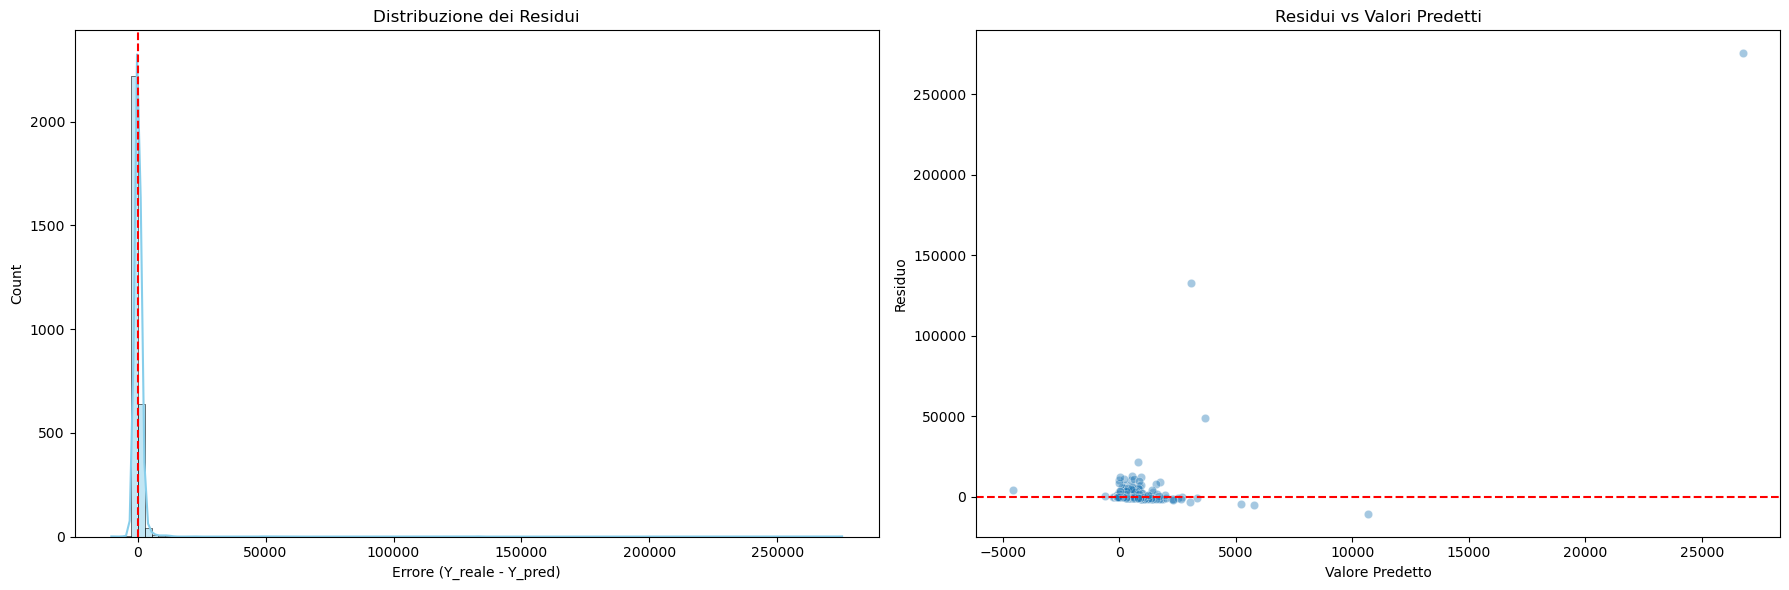

In [15]:


# Calcolo residui se non lo hai già fatto
residuals = y_test - pred_val

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# --- PLOT 1: Distribuzione dei Residui ---
sns.histplot(residuals, kde=True, ax=ax[0], color='skyblue')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title('Distribuzione dei Residui')
ax[0].set_xlabel('Errore (Y_reale - Y_pred)')

# Zoom sugli outlier (opzionale ma consigliato per i tuoi dati)
# ax[0].set_xlim(np.percentile(residuals, 1), np.percentile(residuals, 99))

# --- PLOT 2: Residui vs Predizioni (Check per Eteroschedasticità) ---
sns.scatterplot(x=pred_val, y=residuals, alpha=0.4, ax=ax[1])
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Residui vs Valori Predetti')
ax[1].set_xlabel('Valore Predetto')
ax[1].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

In [16]:
# 1. Creazione del DataFrame di analisi errori partendo da df_val
analysis_df = df_val.copy()
analysis_df['predizione'] = pred_val
analysis_df['residuo'] = analysis_df[target] - analysis_df['predizione']
analysis_df['errore_assoluto'] = analysis_df['residuo'].abs()

# Calcoliamo l'errore percentuale per singolo caso (quello che compone il tuo MAPE)
# Nota: se il target è 0, questo valore sarà infinito
analysis_df['mape_individuale'] = (analysis_df['errore_assoluto'] / analysis_df[target].abs()) * 100

# 2. Identificazione dei 15 peggiori "colpevoli"
top_errors = analysis_df.sort_values(by='errore_assoluto', ascending=False).head(15)

# 3. Visualizzazione dei risultati
cols_to_show = [id_col, time_col, target, 'predizione', 'residuo', 'mape_individuale']
print("--- I 15 PEGGIORI ERRORI DEL MODELLO ---")
print(top_errors[cols_to_show])

# 4. Analisi rapida: gli outlier appartengono a un settore specifico?
print("\n--- SETTORI CON PIÙ ERRORI (TOP 15) ---")
print(top_errors['prev_ateco_sector'].value_counts())

--- I 15 PEGGIORI ERRORI DEL MODELLO ---
      company_id  fiscal_year  revenue_change    predizione        residuo  \
9793  COMP_02485         2021       302126.48  26790.753626  275335.726374   
5876  COMP_01490         2021       136091.65   3075.399263  133016.250737   
3543  COMP_00896         2021        52783.86   3667.505210   49116.354790   
7556  COMP_01915         2021        22529.11    800.100207   21729.009793   
4078  COMP_01031         2021        13690.09    531.387393   13158.702607   
2896  COMP_00733         2021        13277.97    920.213387   12357.756613   
9753  COMP_02475         2021        12294.61     47.019872   12247.590128   
5335  COMP_01352         2021        11849.81    626.487247   11223.322753   
7481  COMP_01896         2021        11361.52    197.961023   11163.558977   
2852  COMP_00722         2021        10995.74    504.403467   10491.336533   
1112  COMP_00283         2021        10359.11      1.787568   10357.322432   
9871  COMP_02505       

# test 2

In [17]:
DELTA_NUM_COLS = [
    "prev_current_ratio",
    "prev_quick_ratio",
    "prev_debt_to_assets",
    "prev_leverage",
    "prev_profit_margin",
    "prev_roi",
    "prev_roe",
    "prev_operating_income",
    "prev_net_profit_loss",
    "prev_total_debt",
    "prev_total_assets",
]
SECTOR_COL = "prev_ateco_sector"


## model training with delta per ateco sector

In [18]:
class InfToNaN(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.replace([np.inf, -np.inf], np.nan)

class AtecoMedianDeltaAdder(BaseEstimator, TransformerMixin):
    def __init__(self, sector_col: str, num_cols: list[str], suffix: str = "d_ateco_med"):
        self.sector_col = sector_col
        self.num_cols = num_cols
        self.suffix = suffix

    def fit(self, X, y=None):
        X = X.copy()

        # global median fallback (train-only)
        self.global_median_ = {
            c: pd.to_numeric(X[c], errors="coerce").median()
            for c in self.num_cols
        }

        df = X[[self.sector_col] + self.num_cols].copy()
        for c in self.num_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        # sector medians (train-only)
        self.sector_median_ = (
            df.groupby(self.sector_col)[self.num_cols]
              .median()
              .to_dict(orient="index")
        )
        return self

    def transform(self, X):
        X = X.copy()
        sectors = X[self.sector_col]

        for c in self.num_cols:
            med = sectors.map(lambda s: self.sector_median_.get(s, {}).get(c, self.global_median_[c]))
            X[f"{c}__{self.suffix}"] = pd.to_numeric(X[c], errors="coerce") - med

        return X

In [22]:


def slog(y):
    y = np.asarray(y, dtype=float)
    return np.sign(y) * np.log1p(np.abs(y))

def inv_slog(z):
    z = np.asarray(z, dtype=float)
    return np.sign(z) * (np.expm1(np.abs(z)))


SECTOR_COL = "prev_ateco_sector"
DELTA_NUM_COLS = [
    "prev_current_ratio",
    "prev_quick_ratio",
    "prev_debt_to_assets",
    "prev_leverage",
    "prev_profit_margin",
    "prev_roi",
    "prev_roe",
    "prev_operating_income",
    "prev_net_profit_loss",
    "prev_total_debt",
    "prev_total_assets",
]


num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_any = ColumnTransformer(
    transformers=[
        ("num", num_pipe, selector(dtype_include=np.number)),
        ("cat", cat_pipe, selector(dtype_include=object)),
    ],
    remainder="drop",
)

xgb = XGBRegressor(
    objective="reg:pseudohubererror",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

delta_model = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ("inf", InfToNaN()),
        ("ateco_delta", AtecoMedianDeltaAdder(SECTOR_COL, DELTA_NUM_COLS, suffix="d_ateco_med")),
        ("feat", feat),                 
        ("prep", preprocess_any),
        ("xgb", xgb),
    ]),
    func=slog,
    inverse_func=inv_slog,
)


delta_model.fit(X_train, y_train)
pred_val_1 = delta_model.predict(X_test)

print("DELTA model on VAL:")
model_performance(y_test, pred_val_1)


DELTA model on VAL:
RMSE: 4,671.947
MAE:  486.913
Directional Acc: 0.748
R2 score:0.4472337384118844
mape:2.410091753671608


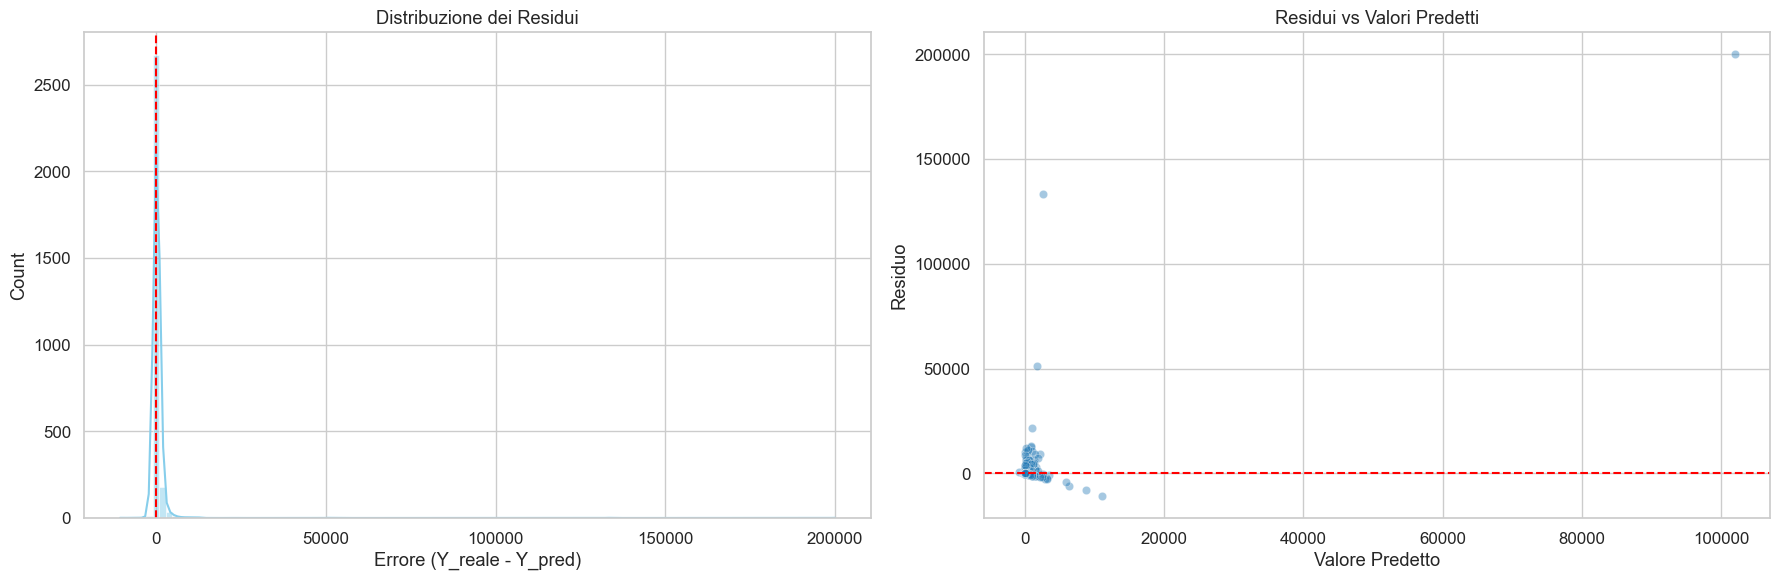

In [23]:
residuals_1 = y_test - pred_val_1

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# --- PLOT 1: Distribuzione dei Residui ---
sns.histplot(residuals_1, kde=True, ax=ax[0], color='skyblue')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title('Distribuzione dei Residui')
ax[0].set_xlabel('Errore (Y_reale - Y_pred)')

# Zoom sugli outlier (opzionale ma consigliato per i tuoi dati)
# ax[0].set_xlim(np.percentile(residuals, 1), np.percentile(residuals, 99))

# --- PLOT 2: Residui vs Predizioni (Check per Eteroschedasticità) ---
sns.scatterplot(x=pred_val, y=residuals_1, alpha=0.4, ax=ax[1])
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Residui vs Valori Predetti')
ax[1].set_xlabel('Valore Predetto')
ax[1].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

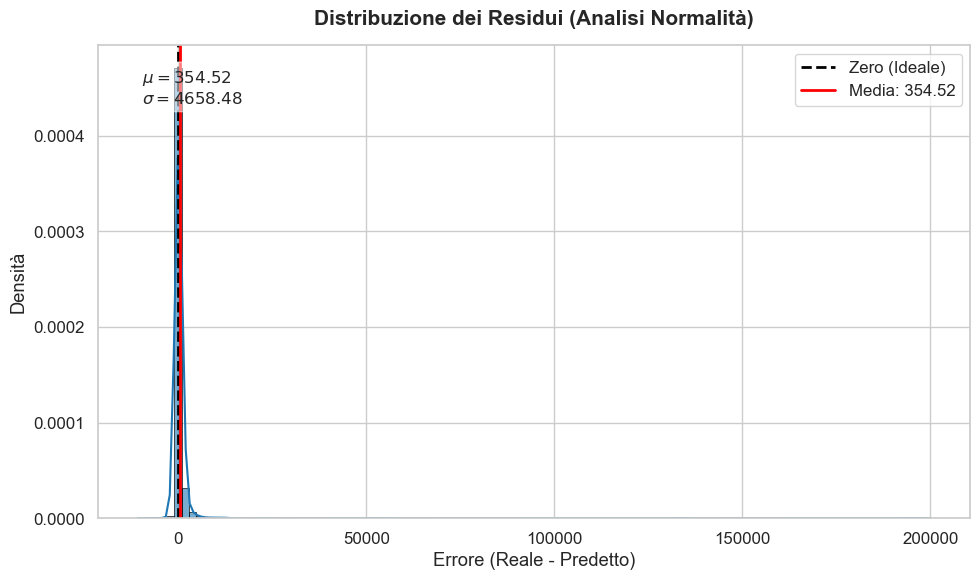

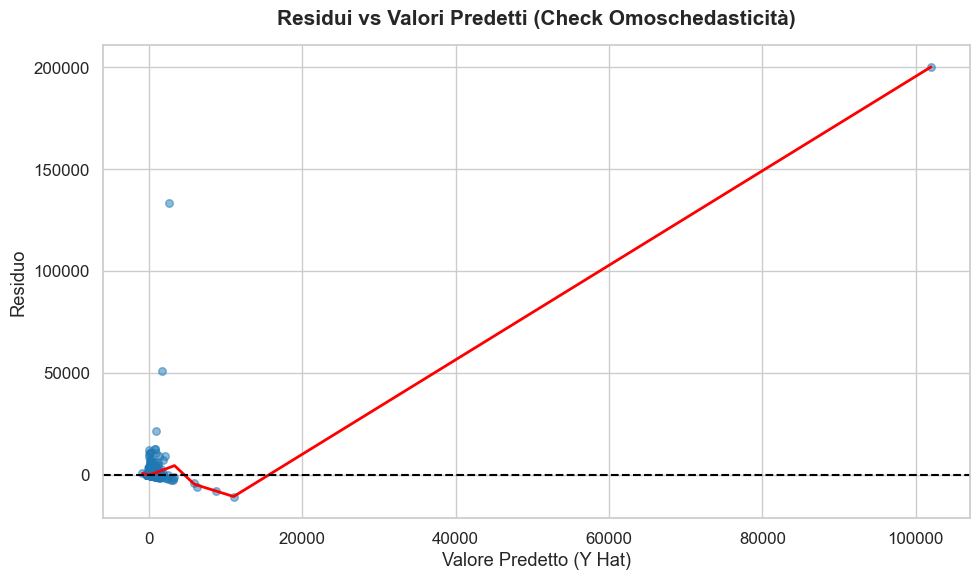

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Impostazioni estetiche globali
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Calcolo preliminare statistiche
mean_resid = np.mean(residuals_1)
std_resid = np.std(residuals_1)

# -------------------------------------------------------
# GRAFICO 1: Distribuzione dei Residui (Istogramma + KDE)
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot principale
sns.histplot(residuals_1, kde=True, color='#1f77b4', edgecolor='black', alpha=0.6, stat="density")

# Linea dello Zero (Ideale)
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero (Ideale)')

# Linea della Media (Bias del modello)
plt.axvline(mean_resid, color='red', linestyle='-', linewidth=2, label=f'Media: {mean_resid:.2f}')

# Titoli e Label
plt.title('Distribuzione dei Residui (Analisi Normalità)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Errore (Reale - Predetto)')
plt.ylabel('Densità')
plt.legend()

# (Opzionale) Box con statistiche
textstr = '\n'.join((
    f'$\mu={mean_resid:.2f}$',
    f'$\sigma={std_resid:.2f}$'))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# GRAFICO 2: Residui vs Predizioni (Analisi Eteroschedasticità)
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Regplot include una linea di regressione (lowess=True aiuta a vedere curve non lineari)
# Scatter_kws gestisce la trasparenza dei punti
# Line_kws gestisce il colore della linea di trend
sns.regplot(x=pred_val, y=residuals_1, 
            lowess=True, 
            scatter_kws={'alpha': 0.5, 'color': '#1f77b4', 's': 30},
            line_kws={'color': 'red', 'linewidth': 2})

# Linea di riferimento orizzontale
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

# Titoli e Label
plt.title('Residui vs Valori Predetti (Check Omoschedasticità)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Valore Predetto (Y Hat)')
plt.ylabel('Residuo')

# Limiti assi (Opzionale: aiuta se ci sono outlier estremi che schiacciano il grafico)
# plt.ylim(np.percentile(residuals_1, 1), np.percentile(residuals_1, 99))

plt.tight_layout()
plt.show()

In [26]:
# 1. Creazione del DataFrame di analisi errori partendo da df_val
analysis_df = df_val.copy()
analysis_df['predizione'] = pred_val_1
analysis_df['residuo'] = analysis_df[target] - analysis_df['predizione']
analysis_df['errore_assoluto'] = analysis_df['residuo'].abs()

# Calcoliamo l'errore percentuale per singolo caso (quello che compone il tuo MAPE)
# Nota: se il target è 0, questo valore sarà infinito
analysis_df['mape_individuale'] = (analysis_df['errore_assoluto'] / analysis_df[target].abs()) * 100

# 2. Identificazione dei 15 peggiori "colpevoli"
top_errors = analysis_df.sort_values(by='errore_assoluto', ascending=False).head(15)

# 3. Visualizzazione dei risultati
cols_to_show = [id_col, time_col, target, 'predizione', 'residuo', 'mape_individuale']
print("--- I 15 PEGGIORI ERRORI DEL MODELLO ---")
print(top_errors[cols_to_show])

# 4. Analisi rapida: gli outlier appartengono a un settore specifico?
print("\n--- SETTORI CON PIÙ ERRORI (TOP 15) ---")
print(top_errors['prev_ateco_sector'].value_counts())

--- I 15 PEGGIORI ERRORI DEL MODELLO ---
      company_id  fiscal_year  revenue_change     predizione        residuo  \
9793  COMP_02485         2021       302126.48  101981.113507  200145.366493   
5876  COMP_01490         2021       136091.65    2593.077478  133498.572522   
3543  COMP_00896         2021        52783.86    1744.467086   51039.392914   
7556  COMP_01915         2021        22529.11     943.766534   21585.343466   
4078  COMP_01031         2021        13690.09     805.967632   12884.122368   
2896  COMP_00733         2021        13277.97     823.801480   12454.168520   
9753  COMP_02475         2021        12294.61      52.807293   12241.802707   
7481  COMP_01896         2021        11361.52     358.931541   11002.588459   
5335  COMP_01352         2021        11849.81     993.248875   10856.561125   
2852  COMP_00722         2021        10995.74     231.472725   10764.267275   
9871  COMP_02505         2021          338.43   11073.504105  -10735.074105   
1112  COMP_